# TSPTW (Occupy): Route Ending at 160 Broadway

Variant of the TSPTW solver where the final stop is fixed to 160 Broadway.
All other locations are optimized freely. Route is a Hamiltonian path.

In [23]:
import numpy as np
import pandas as pd
import psycopg
import matplotlib.pyplot as plt

## Parameters

In [24]:
# 0=Monday, 1=Tuesday, 2=Wednesday, 3=Thursday, 4=Friday, 5=Saturday, 6=Sunday
START_DAY = 5  # Saturday

# Start time as HH:MM
START_TIME = "06:00"

# Walking speed in mph
SPEED_MPH = 6.0

# Fixed final stop
END_ADDRESS = "160 Broadway"

# --- derived ---
DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DAY_ABBR = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

_h, _m = map(int, START_TIME.split(':'))
START_TIME_MIN = _h * 60 + _m
SPEED_M_PER_MIN = SPEED_MPH * 1609.344 / 60

print(f"Start: {DAYS[START_DAY]} at {START_TIME}")
print(f"Speed: {SPEED_MPH} mph = {SPEED_M_PER_MIN:.2f} m/min")
print(f"End:   {END_ADDRESS}")

Start: Saturday at 06:00
Speed: 6.0 mph = 160.93 m/min
End:   160 Broadway


## Load data

In [25]:
conn = psycopg.connect("dbname=mctrot host=127.0.0.1 port=5432")

distances = pd.read_sql("""
    SELECT from_mcd_id, to_mcd_id, distance_meters
    FROM route_summary
""", conn)

locations = pd.read_sql("""
    SELECT
        ogc_fid AS mcd_id,
        addressline1,
        restauranthoursmonday,
        restauranthourstuesday,
        restauranthourswednesday,
        restauranthoursthursday,
        restauranthoursfriday,
        restauranthourssaturday,
        restauranthourssunday,
        ST_Y(the_geog::geometry) AS lat,
        ST_X(the_geog::geometry) AS lon
    FROM mcisland_mcd
    ORDER BY ogc_fid
""", conn)

conn.close()
print(f"{len(locations)} locations, {len(distances)} distance pairs")

47 locations, 2162 distance pairs


/var/folders/xc/gjswmb8n415gsl6jjnd178j40000gn/T/ipykernel_46928/3261352032.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  distances = pd.read_sql("""
/var/folders/xc/gjswmb8n415gsl6jjnd178j40000gn/T/ipykernel_46928/3261352032.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  locations = pd.read_sql("""


In [26]:
ids = locations['mcd_id'].tolist()
idx = {mcd_id: i for i, mcd_id in enumerate(ids)}
N = len(ids)

dist = np.full((N, N), np.inf)
np.fill_diagonal(dist, 0)

for _, row in distances.iterrows():
    i, j = idx[row['from_mcd_id']], idx[row['to_mcd_id']]
    dist[i, j] = row['distance_meters']
    dist[j, i] = row['distance_meters']

# Locate the fixed end stop
end_matches = locations[locations['addressline1'] == END_ADDRESS]
assert len(end_matches) == 1, f"Expected exactly one match for '{END_ADDRESS}', got {len(end_matches)}"
END_POS = locations.index.get_loc(end_matches.index[0])

print(f"Distance matrix: {dist.shape}, missing pairs: {np.isinf(dist).sum()}")
print(f"End stop position in matrix: {END_POS} ({locations.iloc[END_POS]['addressline1']})")

Distance matrix: (47, 47), missing pairs: 0
End stop position in matrix: 46 (160 Broadway)


## Time windows

Parse per-day hours for every location. The `isTwentyFourHours` flag is ignored
because it does not reliably match the per-day columns.

Edge cases:
- `00:00 - 00:00` → open all day (0, 1440)
- `HH:MM - 00:00` → closes at midnight, treat close as 1440
- `HH:MM - HH:MM` where close < open → crosses midnight, add 1440 to close

When checking arrivals, also look at the previous day's window in case
it extends past midnight into the current day.

In [27]:
HOUR_COLS = [
    'restauranthoursmonday',
    'restauranthourstuesday',
    'restauranthourswednesday',
    'restauranthoursthursday',
    'restauranthoursfriday',
    'restauranthourssaturday',
    'restauranthourssunday',
]

def parse_hours(hours_str):
    """Parse 'HH:MM - HH:MM' into (open_min, close_min) as minutes from midnight.

    Returns:
        (0, 1440)   for '00:00 - 00:00' (open all day)
        (open, 1440) for 'HH:MM - 00:00' (closes at midnight)
        (open, close+1440) when close < open (crosses midnight)
        (0, 1440)   when hours_str is None/empty (assume open)
    """
    if not hours_str:
        return (0, 1440)

    open_str, close_str = hours_str.split(' - ')
    oh, om = map(int, open_str.split(':'))
    ch, cm = map(int, close_str.split(':'))

    open_min  = oh * 60 + om
    close_min = ch * 60 + cm

    if open_min == 0 and close_min == 0:
        return (0, 1440)

    if close_min == 0:
        close_min = 1440
    elif close_min < open_min:
        close_min += 1440

    return (open_min, close_min)


windows = [
    {d: parse_hours(row[col]) for d, col in enumerate(HOUR_COLS)}
    for _, row in locations.iterrows()
]

print("Locations with restricted hours (any day):")
for i, (_, row) in enumerate(locations.iterrows()):
    restricted = [
        f"{DAY_ABBR[d]}: {o//60:02d}:{o%60:02d}-{c//60%24:02d}:{c%60:02d}"
        for d, (o, c) in windows[i].items()
        if o > 0 or c < 1440
    ]
    if restricted:
        print(f"  {row['addressline1']}")
        for r in restricted:
            print(f"    {r}")

Locations with restricted hours (any day):
  2379 Adam Clayton Powell Jr Blvd
    Mon: 06:00-00:00
    Tue: 06:00-00:00
    Wed: 06:00-00:00
    Thu: 06:00-00:00
    Fri: 06:00-00:00
    Sat: 06:00-00:00
    Sun: 06:00-00:00
  354 W 125th St
    Mon: 06:00-23:00
    Tue: 06:00-23:00
    Wed: 06:00-23:00
    Thu: 06:00-00:00
    Fri: 06:00-00:00
    Sat: 06:00-00:00
    Sun: 06:00-23:00
  600a W. 125 Street Broadway
    Mon: 06:00-23:00
    Tue: 06:00-23:00
    Wed: 06:00-23:00
    Thu: 06:00-00:00
    Fri: 06:00-00:00
    Sat: 06:00-00:00
    Sun: 06:00-23:00
  3809 Broadway
    Mon: 06:00-23:00
    Tue: 06:00-23:00
    Wed: 06:00-23:00
    Thu: 06:00-02:00
    Fri: 06:00-02:00
    Sat: 06:00-02:00
    Sun: 06:00-23:00
  1872 3rd Ave
    Mon: 06:00-23:00
    Tue: 06:00-23:00
    Wed: 06:00-23:00
    Thu: 06:00-23:00
    Fri: 06:00-00:00
    Sat: 06:00-00:00
    Sun: 06:00-23:00
  1871 2nd Ave
    Mon: 06:00-23:00
    Tue: 06:00-23:00
    Wed: 06:00-23:00
    Thu: 06:00-23:00
    Fri: 0

## TSPTW solver (fixed end)

160 Broadway is pinned to the last position. 2-opt moves are restricted to
positions `0..N-2` so it cannot be displaced.

In [28]:
VIOLATION_PENALTY = 30 * 24 * 60  # 30 days in minutes


def open_at(windows, loc_idx, start_day, absolute_time):
    """Return (is_open, minutes_to_wait) for loc_idx at the given absolute time."""
    day_offset  = int(absolute_time // 1440)
    time_in_day = absolute_time % 1440
    dow         = (start_day + day_offset) % 7
    open_min, close_min = windows[loc_idx][dow]

    if open_min <= time_in_day < close_min:
        return True, 0.0

    if day_offset > 0:
        prev_dow = (start_day + day_offset - 1) % 7
        prev_open, prev_close = windows[loc_idx][prev_dow]
        if prev_close > 1440 and time_in_day < prev_close - 1440:
            return True, 0.0

    if time_in_day < open_min:
        return False, float(open_min - time_in_day)

    next_dow = (dow + 1) % 7
    next_open, _ = windows[loc_idx][next_dow]
    wait = (1440 - time_in_day) + next_open
    return False, float(wait)


def route_cost(route, dist, windows, start_day, start_time_min, speed_m_per_min):
    """Total route cost in minutes (travel + waiting) plus violation penalties."""
    current_time = float(start_time_min)
    violations = 0

    for step, loc_idx in enumerate(route):
        if step > 0:
            travel = dist[route[step - 1], loc_idx] / speed_m_per_min
            arrival = current_time + travel
        else:
            arrival = current_time

        is_open, wait = open_at(windows, loc_idx, start_day, arrival)

        if is_open:
            current_time = arrival
        elif wait > 0 and wait < 1440:
            current_time = arrival + wait
        else:
            violations += 1
            current_time = arrival

    return (current_time - start_time_min) + violations * VIOLATION_PENALTY

In [29]:
def simulated_annealing_tsptw_occupy(
    dist, windows, start_day, start_time_min, speed_m_per_min, end_pos,
    T_start=5000, T_end=0.1, cooling=0.9995, seed=42
):
    rng = np.random.default_rng(seed)
    N = len(dist)

    # Build initial route: random permutation of non-end locations, end_pos last
    others = [i for i in range(N) if i != end_pos]
    route = list(rng.permutation(others)) + [end_pos]

    def cost(r):
        return route_cost(r, dist, windows, start_day, start_time_min, speed_m_per_min)

    best_route = route[:]
    best_cost  = cost(route)
    cur_cost   = best_cost
    T = T_start
    history = []
    iters = 0

    M = N - 1  # number of free positions (everything except the fixed last stop)

    while T > T_end:
        # 2-opt only among the first M positions — end_pos stays fixed at route[-1]
        i, j = sorted(rng.choice(M, 2, replace=False))
        candidate = route[:]
        candidate[i:j+1] = reversed(candidate[i:j+1])

        c_new = cost(candidate)
        delta = c_new - cur_cost

        if delta < 0 or rng.random() < np.exp(-delta / T):
            route    = candidate
            cur_cost = c_new
            if c_new < best_cost:
                best_cost  = c_new
                best_route = route[:]

        T *= cooling
        iters += 1
        if iters % 10_000 == 0:
            history.append(best_cost)

    print(f"Iterations: {iters:,}")
    return best_route, best_cost, history


best_route, best_cost, history = simulated_annealing_tsptw_occupy(
    dist, windows, START_DAY, START_TIME_MIN, SPEED_M_PER_MIN, END_POS
)

violations = int(best_cost // VIOLATION_PENALTY)
travel_min = best_cost - violations * VIOLATION_PENALTY
print(f"Best cost:  {best_cost:.0f} min")
print(f"Violations: {violations}")
print(f"Route time: {travel_min:.0f} min ({travel_min/60:.1f} h)")
print(f"Final stop: {locations.iloc[best_route[-1]]['addressline1']}")

Iterations: 21,635
Best cost:  307 min
Violations: 0
Route time: 307 min (5.1 h)
Final stop: 160 Broadway


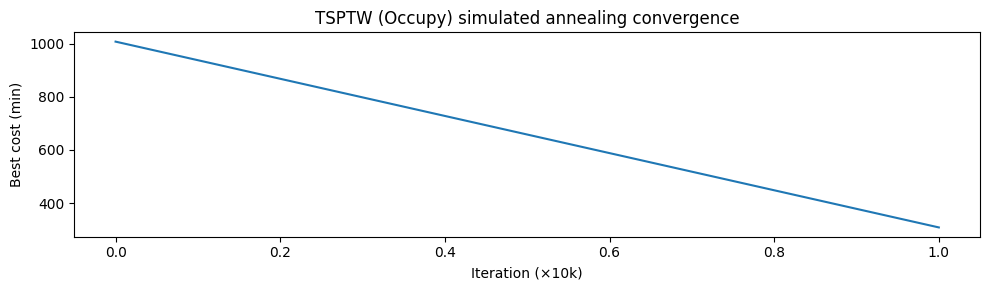

In [30]:
plt.figure(figsize=(10, 3))
plt.plot(history)
plt.xlabel("Iteration (×10k)")
plt.ylabel("Best cost (min)")
plt.title("TSPTW (Occupy) simulated annealing convergence")
plt.tight_layout()
plt.show()

## Route analysis

In [31]:
def fmt_time(absolute_min):
    day_offset  = int(absolute_min // 1440)
    time_in_day = absolute_min % 1440
    dow = (START_DAY + day_offset) % 7
    h = int(time_in_day // 60)
    m = int(time_in_day % 60)
    return f"{DAY_ABBR[dow]} {h:02d}:{m:02d}"


def analyze_route(route):
    current_time = float(START_TIME_MIN)
    rows = []

    for step, loc_idx in enumerate(route):
        if step > 0:
            travel = dist[route[step - 1], loc_idx] / SPEED_M_PER_MIN
            arrival = current_time + travel
        else:
            arrival = current_time
            travel  = 0.0

        is_open, wait = open_at(windows, loc_idx, START_DAY, arrival)

        day_offset  = int(arrival // 1440)
        dow         = (START_DAY + day_offset) % 7
        time_in_day = arrival % 1440
        open_min, close_min = windows[loc_idx][dow]

        if is_open:
            status = 'ok'
            current_time = arrival
        elif wait > 0:
            status = 'wait'
            current_time = arrival + wait
        else:
            status = 'VIOLATION'
            current_time = arrival

        rows.append({
            'stop':        step + 1,
            'address':     locations.iloc[loc_idx]['addressline1'],
            'travel_min':  round(travel, 1),
            'arrival':     fmt_time(arrival),
            'time_window': f"{open_min//60:02d}:{open_min%60:02d}–"
                           f"{(close_min//60)%24:02d}:{close_min%60:02d}"
                           + ("+1" if close_min > 1440 else ""),
            'wait_min':    round(wait, 1) if status == 'wait' else 0,
            'status':      status,
        })

    return pd.DataFrame(rows)


analysis = analyze_route(best_route)

def highlight(row):
    if row['status'] == 'VIOLATION':
        return ['background-color: #ffcccc'] * len(row)
    if row['status'] == 'wait':
        return ['background-color: #fff3cc'] * len(row)
    return [''] * len(row)

analysis.style.apply(highlight, axis=1)

,stop,address,travel_min,arrival,time_window,wait_min,status
0,1,608 West 207th Street,0.000000,Sat 06:00,00:00–00:00,0,ok
1,2,208 Dyckman St,3.500000,Sat 06:03,00:00–00:00,0,ok
2,3,4259 Broadway,11.800000,Sat 06:15,00:00–00:00,0,ok
3,4,4040 Broadway,5.900000,Sat 06:21,00:00–00:00,0,ok
4,5,3809 Broadway,5.700000,Sat 06:26,06:00–02:00+1,0,ok
5,6,3543-49 Broadway,7.000000,Sat 06:33,00:00–00:00,0,ok
6,7,2379 Adam Clayton Powell Jr Blvd,9.500000,Sat 06:43,06:00–00:00,0,ok
7,8,148 W 125th Street,7.000000,Sat 06:50,00:00–00:00,0,ok
8,9,354 W 125th St,2.600000,Sat 06:52,06:00–00:00,0,ok
9,10,600a W. 125 Street Broadway,4.700000,Sat 06:57,06:00–00:00,0,ok


In [32]:
total_travel = analysis['travel_min'].sum()
total_wait   = analysis['wait_min'].sum()
n_violations = (analysis['status'] == 'VIOLATION').sum()
n_waits      = (analysis['status'] == 'wait').sum()

print(f"Stops:          {len(analysis)}")
print(f"Walking time:   {total_travel:.0f} min ({total_travel/60:.1f} h)")
print(f"Waiting time:   {total_wait:.0f} min ({total_wait/60:.1f} h)")
print(f"Total time:     {(total_travel + total_wait):.0f} min ({(total_travel + total_wait)/60:.1f} h)")
print(f"Waits:          {n_waits}")
print(f"Violations:     {n_violations}")
print(f"Final stop:     {analysis.iloc[-1]['address']}")

Stops:          47
Walking time:   307 min (5.1 h)
Waiting time:   0 min (0.0 h)
Total time:     307 min (5.1 h)
Waits:          0
Violations:     0
Final stop:     160 Broadway


## Save to database

In [33]:
conn = psycopg.connect("dbname=mctrot host=127.0.0.1 port=5432")
with conn.cursor() as cur:
    cur.execute("DROP TABLE IF EXISTS tsptw_occupy_route")
    cur.execute("""
        CREATE TABLE tsptw_occupy_route (
            stop_order   INTEGER PRIMARY KEY,
            mcd_id       INTEGER,
            addressline1 TEXT,
            arrival      TEXT,
            time_window  TEXT,
            wait_min     NUMERIC,
            status       TEXT
        )
    """)
    for _, row in analysis.iterrows():
        cur.execute(
            """
            INSERT INTO tsptw_occupy_route
                (stop_order, mcd_id, addressline1, arrival, time_window, wait_min, status)
            VALUES (%s, %s, %s, %s, %s, %s, %s)
            """,
            (
                int(row['stop']),
                int(ids[best_route[int(row['stop']) - 1]]),
                row['address'],
                row['arrival'],
                row['time_window'],
                row['wait_min'],
                row['status'],
            )
        )
conn.commit()
conn.close()
print(f"Written {len(analysis)} rows to tsptw_occupy_route.")

Written 47 rows to tsptw_occupy_route.
